In [2]:
from matplotlib import pyplot as plt
from matplotlib import colors
from matplotlib import patches 
import numpy as np
import pandas as pd
import sys
import os

In [20]:
# Statistics
def combinedError(group, field, se_field):
        N = len(group)
        s = group[field].std()
        sigma_i = group[se_field]
        # combine in quadrature
        total_error = np.sqrt((s**2) / N + (sigma_i**2).sum() / (N**2))
        # total_error = s / np.sqrt(N)
        return pd.Series({
            "mean": group[field].mean(),
            "std": s,
            "mean_se": sigma_i.mean(),
            "error": total_error
        })
    
def getLinearFit(X, Y, error, minx = np.log(8)/8):
    fit = np.polyfit(X, Y, 1, w=1/error**2, cov=False)
    cov = ((0,0),(0,0))
    x = np.linspace(0, minx, 100)
    y = np.polyval(fit, x)
    print(fit)
    return (x, y, cov[0][0])
    
def angleDependence(gamma):
        return (1 / 24) * (0
            + np.pi / gamma
            - gamma / np.pi
            + np.pi / (2*np.pi - gamma)
            - (2*np.pi - gamma) / np.pi
        )

def squareAngleDependence(gamma):
    return 2*angleDependence(gamma) + 2*angleDependence(np.pi - gamma)

In [21]:
# Get 2-point estimate for power laws
def getExponent(filename, col_name, se_name, 
                n=3, 
                law="exp"):
    
    df_raw = pd.read_csv(filename, sep=',')
    df = df_raw.groupby("L")[[col_name, se_name]].apply(lambda x: combinedError(x, col_name, se_name)).reset_index()
    
    

    lowest_size = df.shape[0]-2-n
    X = np.zeros(n)
    Y = np.zeros(n)
    error = np.zeros(n)

    if law == "exp":
        df['logL'] = np.log(df['L'])
        df['1/L'] = 1/df['L']
        df['logX'] = np.log(df['mean'])
        df['SE_logX'] = df['error'] / df['mean']
        
        for i in range(lowest_size, lowest_size+n):
            X[i-lowest_size] = df['1/L'].iloc[i+2]
            Y[i-lowest_size] = (df['logX'].iloc[i+2] - df['logX'].iloc[i]) / (df['logL'].iloc[i+2] - df['logL'].iloc[i])
            error[i-lowest_size] = (
                np.sqrt(
                    df['SE_logX'].iloc[i+2]*df['SE_logX'].iloc[i+2] + 
                    df['SE_logX'].iloc[i]*df['SE_logX'].iloc[i]) / 
                (df['logL'].iloc[i+2] - df['logL'].iloc[i]))
            
    elif law == "b":
        df['l'] = df['L'] // 2
        df['logl'] = np.log(df['l'])
        df['logl/l'] = df['logl'] / df['l']
        
        for i in range(lowest_size, lowest_size+n):
            X[i-lowest_size] = df['logl/l'].iloc[i+2]
            Y[i-lowest_size] = (df['mean'].iloc[i+2] - df['mean'].iloc[i]) / (df['logl'].iloc[i+2] - df['logl'].iloc[i])
            error[i - lowest_size] = (
                np.sqrt(
                    df['error'].iloc[i+2] * df['error'].iloc[i+2] +
                    df['error'].iloc[i]   * df['error'].iloc[i]) /
                (df['logl'].iloc[i+2] - df['logl'].iloc[i]))
            
            
    return (X, Y, error)

In [5]:
# Plotting Functions
def plotFss(ax, X, Y, error, label, color):
    
    miny = min(Y)
    maxy = max(Y)
    ax.errorbar(X, Y, yerr=error, linestyle='--', fmt='.', capsize=3, color=color, label=label)
    
    return (miny, maxy)
    
def plotFssSpines(ax, yrange, xrange, yname, xname, expected=None, legend = True):

    ax.vlines((0,), yrange[0], yrange[1], linestyle='solid', color='black')
    if expected is not None:
        ax.hlines((expected,), xrange[0], xrange[1], linestyle='solid', color='black', label=f'Expected Answer')
    ax.set_ylim(yrange[0], yrange[1])
    ax.set_xlim(xrange[0], xrange[1])
    ax.set_xlabel(xname)
    ax.set_ylabel(yname)
    ax.set_title(f'FSS of {yname}') 
    if legend:
        ax.legend()

[-0.30389861 -0.0617553 ]
[0.08989167 1.84591853]
[-1.27232681  0.4222315 ]


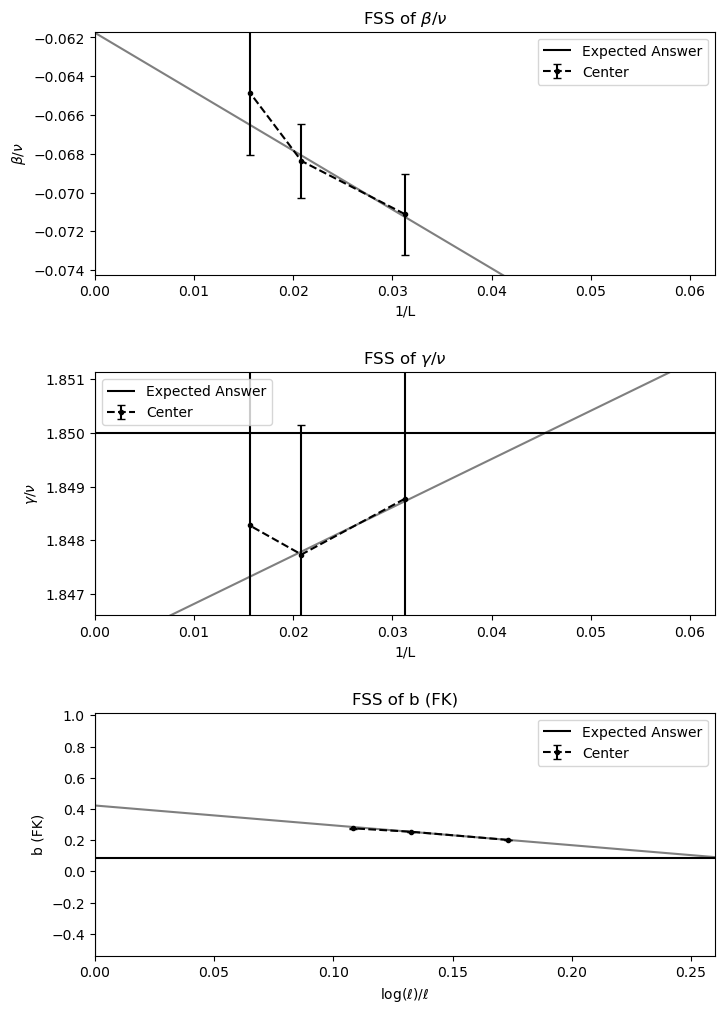

In [26]:
# Plotting Suite
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(8, 12))
fig.subplots_adjust(hspace=0.4)
lines = True
n = 3
root = '/projects/p32813/blume_capel/data/sweep'
dataset_ids = range(1)
datasets = (
    "t3_d3",
    "t3.5_d3",
    "t2.5_d3",
    "t3_d3.5",
    "t3_d2.5"
)
labels = (
    "Center",
    "T+",
    "T-",
    "D+",
    "D-"
)
colors = (
    'black',
    'red',
    'orange',
    'cornflowerblue',
    'blue'
)
observables = [
    {
        "name": r"$\beta / \nu$",
        "filename": "magnet.txt",
        "col": ("m", "se_m"),
        "law": "exp",
        "expected": -0.075,
        "zoom": 0.5,
        "xmax": 1/16,
        "xname": "1/L",
    },
    {
        "name": r"$\gamma / \nu$",
        "filename": "magnet.txt",
        "col": ("X", "se_X"),
        "law": "exp",
        "expected": 1.85,
        "zoom": 0.5,
        "xmax": 1/16,
        "xname": "1/L",
    },
    {
        "name": "b (FK)",
        "filename": "gap/square/spin/8.csv",
        "col": ("corner_contribution", "standard_error"),
        "law": "b",
        "expected": 0.343774677 / 4,
        "zoom": 10,
        "xmax": np.log(8) / 8,
        "xname": r"$\log(\ell)/\ell$",
    },
]
# 0.343774677
zooms = (0.3, 0.3, 0.5)
xmax = (1/16, 1/16, np.log(8)/8)
xnames = ("1/L", "1/L", r"$Log({\ell}) / \ell$")

for i in (0,1,2):
    obs = observables[i]
    miny = 100
    maxy = -100
    for j in dataset_ids:
        X, Y, err = getExponent(f"{root}/{datasets[j]}/{obs['filename']}", 
                                obs['col'][0], obs['col'][1],
                                n,
                                obs['law'])
        low, high = plotFss(axs[i], X, Y, err, labels[j], colors[j])
        miny = min(low, miny)
        maxy = max(high, maxy)
        if lines:
            linX, linY, _ = getLinearFit(X, Y, err, xmax[i])
            axs[i].plot(linX, linY, color=colors[j], alpha=0.5)
    maxy = max(maxy, obs['expected'])
    dy = maxy - miny    
    plotFssSpines(axs[i], 
                  (miny-obs['zoom']*dy, maxy+obs['zoom']*dy), 
                  (0, obs['xmax']), 
                  obs['name'], obs['xname'], 
                  obs['expected'])

fig.show()

In [1]:
root = '/projects/p32813/blume_capel/data/sweep'
dirname = "gap/square/spin"
beta_expected = 0.343774677
datasets = (
    "t3_d3",
    "t3.5_d3",
    "t2.5_d3",
    "t3_d3.5",
    "t3_d2.5"
)
styles = (
    dict(marker='o', color='green'),
    dict(marker='^', color='blue'),
    dict(marker='+', color='magenta'),
    dict(marker='D', color='black')
)
labels = (
    r"$\ell = 8-16$",
    r"$\ell = 12-24$",
    r"$\ell = 16-32$",
    r"$\ell \rightarrow \infty$"
)
    
n_datasets = 5
n_points = 3
n_gamma = 8

ls = (32, 24, 16)
gammas = np.zeros(n_gamma)
bs = np.zeros((n_points+1, n_gamma))
errs = np.zeros((n_points+1, n_gamma))

# Loop through all Gamma
for i in range(n_gamma):
    fname = f"{root}/{datasets[0]}/{dirname}/{i}.csv"
    gammas[i] = float(pd.read_csv(fname)['gamma'].iloc[0]) * (np.pi / 180)
    
    berr = np.zeros(n_points)
    b0 = np.zeros(n_points + 1)
    # Loop through different datasets for systematic error
    for j in range(n_datasets):
        fname = f"{root}/{datasets[j]}/{dirname}/{i}.csv"
        X, Y, err = getExponent(fname, "corner_contribution", "standard_error",
                                    n_points, 'b')
        b_inf = getLinearFit(X, Y, err)[1][0]
        # Loop through different 2-point estimates
        for k in range(n_points):
            if j == 0:
                bs[k, i] = Y[k]
            errs[k, i] = max(abs(Y[k] - bs[k,i]), errs[k, i])
            
        if j == 0:
            bs[n_points, i] = b_inf
        errs[n_points, i] = max(abs(b_inf - bs[n_points, i]), errs[n_points, i])

# Plot all ls
for k in range(n_points + 1):
    plt.errorbar(
        gammas, bs[k], errs[k],
        linestyle='-', linewidth=1.2,
        markersize=4, capsize=3, fillstyle='none',
        label=labels[k],
        **styles[k])

# Plot expected
X = np.linspace(gammas[n_gamma-1], gammas[0], 100)
plt.plot(X, beta_expected * squareAngleDependence(X), color = 'red', label="Expected")
plt.plot(X, (bs[n_points, 0] / squareAngleDependence(gammas[0])) * squareAngleDependence(X), 
         color = 'gray', label=fr"Geometric extrapolation from $\gamma = \pi / 2$")
plt.fill_between(X, ((bs[n_points, 0] + errs[n_points,0]) / squareAngleDependence(gammas[0])) * squareAngleDependence(X),
                ((bs[n_points, 0] - errs[n_points,0]) / squareAngleDependence(gammas[0])) * squareAngleDependence(X), 
                color='gray', alpha=0.2)

# Plot extrapolated from gamma0


plt.xscale("log")
plt.xlabel(r"$\gamma$")
plt.ylabel(r"$b$")
plt.title("Angle Dependence of b for Sheared Squares")
plt.legend()
plt.show()

NameError: name 'np' is not defined

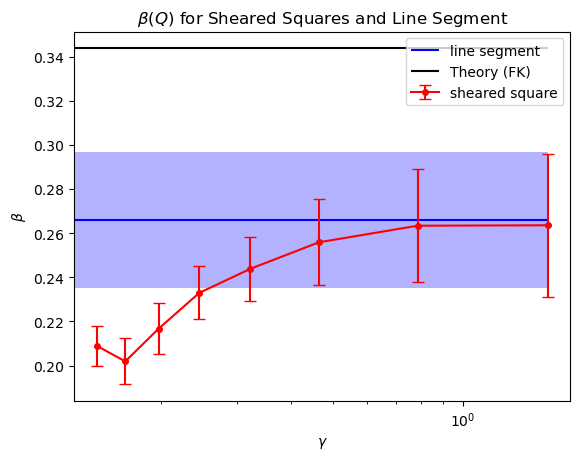

In [68]:
# Line segment
line_segment_fname = "gap/spin.txt"
ls_err = 0
ls_beta = 0
# Line segment
for j in range(n_datasets):
    fname = f"{root}/{datasets[j]}/{line_segment_fname}"
    X, Y, err = getExponent(fname, "corner_contribution", "standard_error",
                                n_points, 'b')
    bj = getLinearFit(X, Y, err)[1][0]
    betaj = bj * 4
    if j == 0:
        ls_beta = betaj
    ls_err = max(ls_err, abs(ls_beta - betaj))
    
# Sheared square (recycle from above)
betas = bs[n_points] / squareAngleDependence(gammas)
beta_errs = errs[n_points] / squareAngleDependence(gammas)

# Plot
plt.hlines(ls_beta, 0, np.pi/2, label="line segment", color='blue')
rect = patches.Rectangle((0, ls_beta - ls_err), np.pi/2, ls_err*2,  
                         edgecolor='none', linewidth=0.2,
                         facecolor='blue', alpha=0.3)
plt.gca().add_patch(rect)
plt.errorbar(gammas, betas, beta_errs,
             color='red', marker='.', markersize = 8, capsize = 4,
             label='sheared square')
plt.hlines(beta_expected, 0, np.pi/2, label="Theory (FK)", color="black")

plt.xscale("log")
plt.xlabel(r"$\gamma$")
plt.ylabel(r"$\beta$")
plt.title(r"$\beta(Q)$ for Sheared Squares and Line Segment")
plt.legend()
plt.show()

0
